# Hotel Booking Demand Portfolio Project

## Project Overview

This project analyzes hotel booking demand data to understand cancellation behavior, booking patterns, and customer/channel performance. The business goal is to identify the factors associated with booking cancellations and translate the findings into operational recommendations.


## Business Context

Hotels face uncertainty from booking cancellations and fluctuating demand. High cancellation rates can affect occupancy forecasting, staffing, pricing, revenue planning, and marketing efficiency.

This project focuses on three business questions:

1. Which factors are associated with higher booking cancellation rates?
2. How do booking patterns differ between City Hotel and Resort Hotel?
3. Which customer segments and distribution channels appear to bring more stable demand?


## Analysis Plan

This notebook follows a realistic data analysis workflow:

- Load and inspect the dataset
- Check data quality issues
- Clean and prepare the data
- Create useful derived features
- Explore booking patterns and cancellation behavior
- Summarize insights and business recommendations


## Key Metrics

To keep the analysis focused, this project pays attention to three core metrics:

1. **Cancellation Rate**: the share of bookings that were canceled.
2. **Booking Volume**: the number of bookings across time, customer, and channel dimensions.
3. **ADR (Average Daily Rate)**: a pricing metric used to compare room price patterns across hotel types and room categories.


In [1]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11


## Variables Description

Before starting the analysis, it is useful to build a compact data dictionary. This makes the notebook easier to follow and improves its quality as a portfolio project.

The table below summarizes the main variables used in this project.


In [2]:
data_dictionary = pd.DataFrame([
    ["hotel", "Categorical", "Type of hotel: City Hotel or Resort Hotel"],
    ["is_canceled", "Binary", "Whether the booking was canceled (1) or not (0)"],
    ["lead_time", "Numeric", "Number of days between booking date and arrival date"],
    ["arrival_date_year", "Numeric", "Arrival year"],
    ["arrival_date_month", "Categorical", "Arrival month"],
    ["arrival_date_week_number", "Numeric", "Week number of the arrival date"],
    ["arrival_date_day_of_month", "Numeric", "Day of the month of arrival"],
    ["stays_in_weekend_nights", "Numeric", "Number of weekend nights booked"],
    ["stays_in_week_nights", "Numeric", "Number of weekday nights booked"],
    ["adults", "Numeric", "Number of adults"],
    ["children", "Numeric", "Number of children"],
    ["babies", "Numeric", "Number of babies"],
    ["meal", "Categorical", "Meal plan booked"],
    ["country", "Categorical", "Country of origin of the guest"],
    ["market_segment", "Categorical", "Market segment designation"],
    ["distribution_channel", "Categorical", "Booking distribution channel"],
    ["is_repeated_guest", "Binary", "Whether the guest is a returning guest"],
    ["previous_cancellations", "Numeric", "Number of previous canceled bookings by the customer"],
    ["previous_bookings_not_canceled", "Numeric", "Number of previous non-canceled bookings by the customer"],
    ["reserved_room_type", "Categorical", "Room type originally reserved"],
    ["assigned_room_type", "Categorical", "Room type actually assigned"],
    ["booking_changes", "Numeric", "Number of booking changes made before arrival"],
    ["deposit_type", "Categorical", "Type of deposit made for the booking"],
    ["agent", "Categorical/Numeric", "ID of the travel agent that made the booking"],
    ["company", "Categorical/Numeric", "ID of the company or entity that made the booking"],
    ["days_in_waiting_list", "Numeric", "Number of days the booking was in the waiting list"],
    ["customer_type", "Categorical", "Type of booking/customer"],
    ["adr", "Numeric", "Average Daily Rate, a proxy for room price"],
    ["required_car_parking_spaces", "Numeric", "Number of parking spaces required"],
    ["total_of_special_requests", "Numeric", "Number of special requests made by the customer"],
    ["reservation_status", "Categorical", "Final reservation status"],
    ["reservation_status_date", "Date", "Date when the last reservation status was set"]
], columns=["variable", "type", "description"])

data_dictionary


,variable,type,description
0,hotel,Categorical,Type of hotel: City Hotel or Resort Hotel
1,is_canceled,Binary,Whether the booking was canceled (1) or not (0)
2,lead_time,Numeric,Number of days between booking date and arriva...
3,arrival_date_year,Numeric,Arrival year
4,arrival_date_month,Categorical,Arrival month
5,arrival_date_week_number,Numeric,Week number of the arrival date
6,arrival_date_day_of_month,Numeric,Day of the month of arrival
7,stays_in_weekend_nights,Numeric,Number of weekend nights booked
8,stays_in_week_nights,Numeric,Number of weekday nights booked
9,adults,Numeric,Number of adults


## Variable Categories

To make the dataset easier to understand, the 32 variables are grouped into six analytical categories below.


In [3]:
variable_categories = {
    "Temporal": [
        "arrival_date_year",
        "arrival_date_month",
        "arrival_date_week_number",
        "arrival_date_day_of_month",
        "reservation_status_date"
    ],
    "Customer": [
        "adults",
        "children",
        "babies",
        "country",
        "customer_type",
        "is_repeated_guest",
        "total_of_special_requests",
        "required_car_parking_spaces"
    ],
    "Booking Behavior": [
        "lead_time",
        "booking_changes",
        "previous_cancellations",
        "previous_bookings_not_canceled",
        "days_in_waiting_list",
        "deposit_type",
        "meal"
    ],
    "Channels": [
        "market_segment",
        "distribution_channel",
        "agent",
        "company"
    ],
    "Revenue & Product": [
        "hotel",
        "adr",
        "reserved_room_type",
        "assigned_room_type",
        "stays_in_week_nights",
        "stays_in_weekend_nights"
    ],
    "Outcome": [
        "is_canceled",
        "reservation_status"
    ]
}

max_len = max(len(v) for v in variable_categories.values())
category_table = pd.DataFrame({
    key: values + [""] * (max_len - len(values))
    for key, values in variable_categories.items()
})

category_table


,Temporal,Customer,Booking Behavior,Channels,Revenue & Product,Outcome
0,arrival_date_year,adults,lead_time,market_segment,hotel,is_canceled
1,arrival_date_month,children,booking_changes,distribution_channel,adr,reservation_status
2,arrival_date_week_number,babies,previous_cancellations,agent,reserved_room_type,
3,arrival_date_day_of_month,country,previous_bookings_not_canceled,company,assigned_room_type,
4,reservation_status_date,customer_type,days_in_waiting_list,,stays_in_week_nights,
5,,is_repeated_guest,deposit_type,,stays_in_weekend_nights,
6,,total_of_special_requests,meal,,,
7,,required_car_parking_spaces,,,,


In [4]:
file_path = "../data/hotel_bookings.csv"
df = pd.read_csv(file_path)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()


Rows: 119,390
Columns: 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Initial Data Understanding

The first step is to understand the structure of the dataset, data types, missing values, and potential data quality issues.


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [6]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "null_count": df.isna().sum(),
    "null_pct": (df.isna().sum() / len(df) * 100).round(2),
    "n_unique": df.nunique()
})

summary.sort_values("null_pct", ascending=False).head(15)


,dtype,null_count,null_pct,n_unique
company,float64,112593,94.31,352
agent,float64,16340,13.69,333
country,str,488,0.41,177
hotel,str,0,0.00,2
previous_cancellations,int64,0,0.00,15
reservation_status,str,0,0.00,3
total_of_special_requests,int64,0,0.00,6
required_car_parking_spaces,int64,0,0.00,5
adr,float64,0,0.00,8879
customer_type,str,0,0.00,4


In [7]:
null_like_counts = {}
for col in df.columns:
    if df[col].dtype == "object":
        null_like_counts[col] = (df[col].astype(str).str.upper() == "NULL").sum()

pd.Series(null_like_counts).sort_values(ascending=False).head(10)


Series([], dtype: object)

## Data Quality Check

At this stage, the goal is to separate three different issues:

- True missing values: fields that are blank or unavailable
- Pseudo-missing values: fields stored as the string `NULL`
- Potentially invalid records: rows that do not make sense for stay analysis

This distinction matters because not every unusual value should be deleted. Some values should be standardized, some should be imputed, and only clearly invalid records should be removed.


In [8]:
quality_check = pd.DataFrame({
    "pseudo_null_count": df.astype(str).apply(lambda s: s.str.upper().eq("NULL").sum()),
    "true_null_count": df.isna().sum()
})

quality_check["combined_missing_like"] = (
    quality_check["pseudo_null_count"] + quality_check["true_null_count"]
)

quality_check.sort_values("combined_missing_like", ascending=False).head(10)


,pseudo_null_count,true_null_count,combined_missing_like
company,0,112593,112593
agent,0,16340,16340
country,0,488,488
children,0,4,4
reserved_room_type,0,0,0
assigned_room_type,0,0,0
booking_changes,0,0,0
deposit_type,0,0,0
hotel,0,0,0
previous_cancellations,0,0,0


In [9]:
exact_duplicate_count = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_duplicate_count:,}")

df[df.duplicated()].head()


Exact duplicate rows: 31,994


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08


In [10]:
potential_issues = pd.Series({
    "negative_adr": (df["adr"] < 0).sum(),
    "zero_adults": (df["adults"] == 0).sum(),
    "zero_total_nights": ((df["stays_in_weekend_nights"] + df["stays_in_week_nights"]) == 0).sum(),
    "zero_total_guests": ((df["adults"] + df["children"].fillna(0) + df["babies"]) == 0).sum()
})

potential_issues.to_frame("row_count")


,row_count
negative_adr,1
zero_adults,403
zero_total_nights,715
zero_total_guests,180


## 1st Round Data Cleaning

Before cleaning the dataset, this notebook follows a simple rule-based logic:

1. Identify true missing values and pseudo-missing values
2. Standardize pseudo-missing values by converting `NULL` into `NaN`
3. Check and remove only exact duplicate rows
4. Fill selected fields only when the business meaning is clear
5. Remove clearly invalid rows only after totals and validation fields are created
6. Create derived fields for later analysis

This order is important because duplicate detection and invalid-value checks are more reliable after missing-like values have been standardized.


In [11]:
df_clean = df.copy()

# Step 1. Standardize pseudo-missing values
df_clean = df_clean.replace("NULL", np.nan)

# Step 2. Check and remove exact duplicate rows only
duplicate_mask = df_clean.duplicated()
duplicate_rows = df_clean.loc[duplicate_mask].copy()
df_clean = df_clean.loc[~duplicate_mask].copy()

# Step 3. Fill selected missing values when the business meaning is clear
df_clean["children"] = df_clean["children"].fillna(0)

# Step 4. Create validation and analysis helper fields
df_clean["total_nights"] = (
    df_clean["stays_in_weekend_nights"] + df_clean["stays_in_week_nights"]
)

# Create a total guests feature.
df_clean["total_guests"] = (
    df_clean["adults"] + df_clean["children"] + df_clean["babies"]
)

# Build a usable arrival_date column.
df_clean["arrival_date"] = pd.to_datetime(
    df_clean["arrival_date_year"].astype(str)
    + "-"
    + df_clean["arrival_date_month"].astype(str)
    + "-"
    + df_clean["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d",
    errors="coerce"
)

# Flag a few simple behavioral features.
df_clean["is_family"] = np.where(df_clean["total_guests"] > 2, 1, 0)
df_clean["same_room_assigned"] = np.where(
    df_clean["reserved_room_type"] == df_clean["assigned_room_type"], 1, 0
)

# Step 5. Identify rows that are clearly invalid for stay-level analysis
invalid_mask = (df_clean["adr"] < 0) | (df_clean["total_guests"] <= 0)
removed_rows = df_clean.loc[invalid_mask].copy()

# Step 6. Remove invalid rows after validation fields are available
df_clean = df_clean.loc[~invalid_mask].copy()

print(f"Cleaned rows: {df_clean.shape[0]:,}")
print(f"Exact duplicate rows removed: {len(duplicate_rows):,}")
print(f"Removed rows: {len(df) - len(df_clean):,}")
print(f"Rows with adr = 0 kept in dataset: {(df_clean['adr'] == 0).sum():,}")


Cleaned rows: 87,229
Exact duplicate rows removed: 31,994
Removed rows: 32,161
Rows with adr = 0 kept in dataset: 1,643


In [12]:
df_clean[[
    "hotel", "is_canceled", "lead_time", "adr", "total_nights",
    "total_guests", "is_family", "same_room_assigned", "arrival_date"
]].head()


,hotel,is_canceled,lead_time,adr,total_nights,total_guests,is_family,same_room_assigned,arrival_date
0,Resort Hotel,0,342,0.0,0,2.0,0,1,2015-07-01
1,Resort Hotel,0,737,0.0,0,2.0,0,1,2015-07-01
2,Resort Hotel,0,7,75.0,1,1.0,0,0,2015-07-01
3,Resort Hotel,0,13,75.0,1,1.0,0,1,2015-07-01
4,Resort Hotel,0,14,98.0,2,2.0,0,1,2015-07-01


### Cleaning Narrative

The first-round cleaning focused on standardizing the dataset before analysis rather than aggressively deleting records. Pseudo-missing values stored as `NULL` were converted into proper `NaN` values, exact duplicate rows were removed, and only the `children` field was imputed with `0` because it is a count variable with clear business meaning.

After that, helper fields such as `total_nights`, `total_guests`, and `arrival_date` were created to support validation and analysis. Invalid rows were removed only when they were clearly not meaningful for stay-level analysis, such as bookings with negative ADR or zero total guests. At the same time, rows with `adr = 0` were intentionally kept because zero-price stays can still be valid in real hotel operations.


## Exploratory Data Analysis (EDA)

This section is the exploratory data analysis stage of the project. Here, we use tables and charts to explore the dataset before writing any formal conclusions.

To keep the analysis structured, the EDA is organized into two parts. First, we look at overall booking patterns. Then, we focus on cancellation behavior across different dimensions.

- Booking patterns
- Customer analysis
- Booking behavior
- Cancellation analysis

The goal of this stage is to generate initial insights that will later be translated into business findings and recommendations.


## EDA 1. Booking Patterns

This block focuses on the overall shape of demand before moving into cancellation analysis. The goal is to understand when guests book, where they come from, and how room price varies across room types and hotel categories.


In [13]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
month_abbr_map = {
    "January": "Jan", "February": "Feb", "March": "Mar", "April": "Apr",
    "May": "May", "June": "Jun", "July": "Jul", "August": "Aug",
    "September": "Sep", "October": "Oct", "November": "Nov", "December": "Dec"
}
month_abbr_order = [month_abbr_map[m] for m in month_order]

df_clean["arrival_date_month"] = pd.Categorical(
    df_clean["arrival_date_month"],
    categories=month_order,
    ordered=True
)
df_clean["arrival_month_short"] = pd.Categorical(
    df_clean["arrival_date_month"].map(month_abbr_map),
    categories=month_abbr_order,
    ordered=True
)

lead_time_band_order = ["0-7", "8-30", "31-90", "91-180", "181+"]
df_clean["lead_time_band"] = pd.cut(
    df_clean["lead_time"],
    bins=[-1, 7, 30, 90, 180, np.inf],
    labels=lead_time_band_order
)

lead_time_heatmap_data = {
    hotel: (
        df_clean[df_clean["hotel"] == hotel]
        .pivot_table(
            index="lead_time_band",
            columns="arrival_month_short",
            values="hotel",
            aggfunc="count",
            fill_value=0,
            observed=False
        )
        .reindex(index=lead_time_band_order, columns=month_abbr_order)
    )
    for hotel in df_clean["hotel"].dropna().unique()
}

top_countries = (
    df_clean["country"].value_counts(normalize=True)
    .loc[lambda s: s >= 0.03]
    .index
    .tolist()
)

country_share = (
    df_clean[df_clean["country"].isin(top_countries)]
    .groupby(["hotel", "country"], observed=False)
    .size()
    .reset_index(name="bookings")
)
country_share["share_pct"] = (
    country_share["bookings"]
    / country_share.groupby("hotel")["bookings"].transform("sum")
    * 100
).round(2)

room_price_data = df_clean[
    (df_clean["is_canceled"] == 0)
    & (df_clean["adr"] > 0)
    & (df_clean["reserved_room_type"].isin(df_clean["reserved_room_type"].value_counts().head(6).index))
].copy()

room_type_order = room_price_data.groupby("reserved_room_type")["adr"].median().sort_values().index

monthly_adr = (
    room_price_data.groupby(["hotel", "arrival_month_short"], observed=False)["adr"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

channel_contribution = (
    df_clean[df_clean["is_canceled"] == 0]
    .groupby(["hotel", "distribution_channel"], observed=False)
    .agg(
        bookings=("hotel", "size"),
        avg_adr=("adr", "mean"),
        total_guests=("total_guests", "sum")
    )
    .reset_index()
)

channel_order = (
    channel_contribution.groupby("distribution_channel")["bookings"]
    .sum()
    .sort_values(ascending=False)
    .index
)

market_segment_share = (
    df_clean[df_clean["is_canceled"] == 0]
    .groupby(["hotel", "market_segment"], observed=False)
    .size()
    .reset_index(name="bookings")
)
market_segment_share["share_pct"] = (
    market_segment_share["bookings"]
    / market_segment_share.groupby("hotel")["bookings"].transform("sum")
    * 100
).round(2)

top_market_segments = (
    market_segment_share.groupby("market_segment")["bookings"]
    .sum()
    .sort_values(ascending=False)
    .head(6)
    .index
)

monthly_guest_volume = (
    df_clean.groupby(["hotel", "arrival_month_short"], observed=False)["total_guests"]
    .sum()
    .reset_index(name="total_guests")
)

monthly_guest_mix = (
    df_clean.groupby(["hotel", "arrival_month_short"], observed=False)[["adults", "children", "babies"]]
    .sum()
    .reset_index()
    .melt(
        id_vars=["hotel", "arrival_month_short"],
        value_vars=["adults", "children", "babies"],
        var_name="guest_type",
        value_name="guest_count"
    )
)


### EDA 1.1 Booking Lead Time Patterns

To understand booking timing, we compare lead time bands across arrival months for each hotel type.


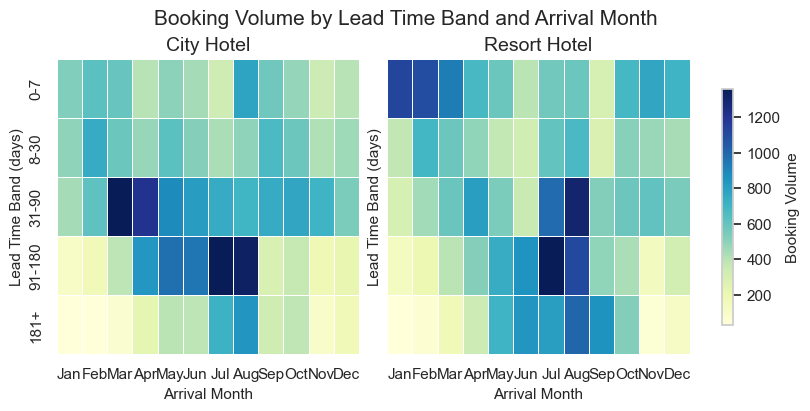

In [47]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(8, 4),
    sharey=True,
    constrained_layout=True   # ⭐关键
)

for ax, hotel in zip(axes, ["City Hotel", "Resort Hotel"]):
    sns.heatmap(
        lead_time_heatmap_data[hotel],
        cmap="YlGnBu",
        linewidths=0.5,
        cbar=False,
        ax=ax
    )
    ax.set_title(hotel)
    ax.set_xlabel("Arrival Month")
    ax.set_ylabel("Lead Time Band (days)")

# 用最后一个heatmap的mappable
cbar = fig.colorbar(
    axes[1].collections[0],
    ax=axes,
    location="right",
    shrink=0.8
)

cbar.set_label("Booking Volume")

fig.suptitle(
    "Booking Volume by Lead Time Band and Arrival Month",
    fontsize=15
)

plt.show()

city hotel：全年比较稳定 + 旺季提前订

resort hotel：季节性更强 + 旺季提前订 + 淡季随意订

In [15]:
lead_time_summary = (
    df_clean.groupby(["hotel", "lead_time_band"], observed=False)
    .size()
    .reset_index(name="bookings")
)
lead_time_summary["share_pct"] = (
    lead_time_summary["bookings"]
    / lead_time_summary.groupby("hotel")["bookings"].transform("sum")
    * 100
).round(2)

lead_time_summary


,hotel,lead_time_band,bookings,share_pct
0,City Hotel,0-7,9800,18.40
1,City Hotel,8-30,10517,19.74
2,City Hotel,31-90,15156,28.45
3,City Hotel,91-180,11556,21.69
4,City Hotel,181+,6245,11.72
5,Resort Hotel,0-7,8403,24.75
6,Resort Hotel,8-30,5809,17.11
7,Resort Hotel,31-90,7564,22.28
8,Resort Hotel,91-180,6668,19.64
9,Resort Hotel,181+,5511,16.23


### EDA 1.2 Guest Origin Patterns

This view highlights the major guest origin countries that account for at least 3% of bookings in the cleaned dataset.


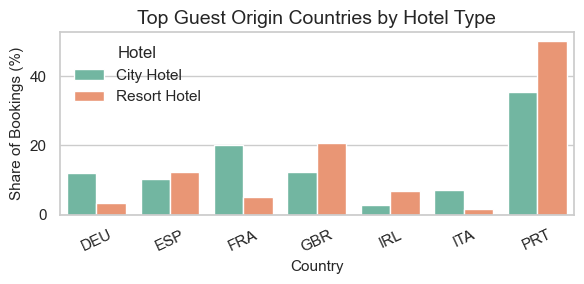

In [49]:
plt.figure(figsize=(6, 3))
sns.barplot(
    data=country_share,
    x="country",
    y="share_pct",
    hue="hotel",
    palette="Set2"
)
plt.title("Top Guest Origin Countries by Hotel Type")
plt.xlabel("Country")
plt.ylabel("Share of Bookings (%)")
plt.xticks(rotation=25)
plt.legend(title="Hotel", frameon=False)
plt.tight_layout()
plt.show()


In [17]:
country_share.sort_values(["hotel", "share_pct"], ascending=[True, False]).reset_index(drop=True)


,hotel,country,bookings,share_pct
0,City Hotel,PRT,13124,35.48
1,City Hotel,FRA,7399,20.00
2,City Hotel,GBR,4520,12.22
3,City Hotel,DEU,4465,12.07
4,City Hotel,ESP,3777,10.21
5,City Hotel,ITA,2642,7.14
6,City Hotel,IRL,1067,2.88
7,Resort Hotel,PRT,14231,50.26
8,Resort Hotel,GBR,5903,20.85
9,Resort Hotel,ESP,3467,12.25


### EDA 1.3 Price and Room Type Patterns

To compare pricing structure, we focus on non-canceled bookings and examine how ADR differs across reserved room types in each hotel category.


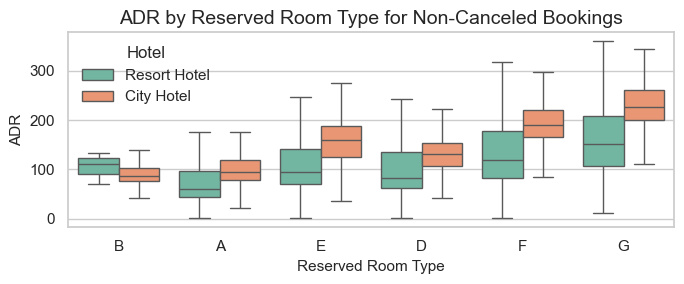

In [50]:
plt.figure(figsize=(7, 3))
sns.boxplot(
    data=room_price_data,
    x="reserved_room_type",
    y="adr",
    hue="hotel",
    order=room_type_order,
    showfliers=False,
    palette="Set2"
)
plt.title("ADR by Reserved Room Type for Non-Canceled Bookings")
plt.xlabel("Reserved Room Type")
plt.ylabel("ADR")
plt.legend(title="Hotel", frameon=False)
plt.tight_layout()
plt.show()


insight：两家酒店对比，除了“基础房型”B以外，其他房型基本呈如下趋势，由于房型只是代码并不一定是完全一致的客房，所以仅对比价格水平和区间。
city hotel平均价格高且价差变化幅度小，resort hotel平均价格低且变化幅度大。

In [19]:
room_price_summary = (
    room_price_data.groupby(["hotel", "reserved_room_type"], observed=False)["adr"]
    .agg(["median", "mean", "count"])
    .reset_index()
    .sort_values(["hotel", "median"], ascending=[True, True])
)

room_price_summary


,hotel,reserved_room_type,median,mean,count
1,City Hotel,B,86.850,91.324946,649
0,City Hotel,A,95.000,100.229497,26417
2,City Hotel,D,130.330,130.775573,6978
3,City Hotel,E,159.450,159.828765,972
4,City Hotel,F,189.000,190.355553,1048
5,City Hotel,G,225.950,226.559423,312
6,Resort Hotel,A,60.000,77.035086,14298
8,Resort Hotel,D,82.000,102.626024,5003
9,Resort Hotel,E,95.000,112.057218,3328
7,Resort Hotel,B,110.000,104.666667,3


### EDA 1.4 Monthly ADR Patterns

This view shows how room price changes across months for non-canceled bookings in each hotel type.


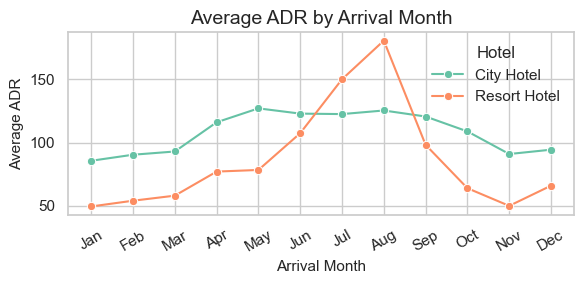

In [51]:
plt.figure(figsize=(6, 3))
sns.lineplot(
    data=monthly_adr,
    x="arrival_month_short",
    y="mean",
    hue="hotel",
    marker="o",
    palette="Set2"
)
plt.title("Average ADR by Arrival Month")
plt.xlabel("Arrival Month")
plt.ylabel("Average ADR")
plt.xticks(rotation=30)
plt.legend(title="Hotel", frameon=False)
plt.tight_layout()
plt.show()


ADR折线图也印证了上述说法，city hotel比较平稳而Resort hotel变化剧烈。

具体来说，city hotel 5-9月价格较高，在120-130EUR区间，，11月至次年2月价格较低； resort hotel具有明显淡旺季，冬季11月到次年3月是淡季，不过12月份有圣诞元旦，ADR稍有反弹，但影响不大。7、8月份价格最高，平均房价在150-190欧元。。

In [21]:
monthly_adr.sort_values(["hotel", "arrival_month_short"]).reset_index(drop=True)


,hotel,arrival_month_short,mean,median,count
0,City Hotel,Jan,85.604387,80.300,1910
1,City Hotel,Feb,90.385871,85.000,2555
2,City Hotel,Mar,92.941241,88.065,3408
3,City Hotel,Apr,116.066816,109.200,3273
4,City Hotel,May,127.085394,123.430,3591
5,City Hotel,Jun,122.936607,117.900,3413
6,City Hotel,Jul,122.562945,116.100,3756
7,City Hotel,Aug,125.413125,119.000,4374
8,City Hotel,Sep,120.631075,115.000,3070
9,City Hotel,Oct,108.850807,104.400,2973


### EDA 1.5 Distribution Structure

This block compares non-canceled booking contribution by distribution channel and market segment.


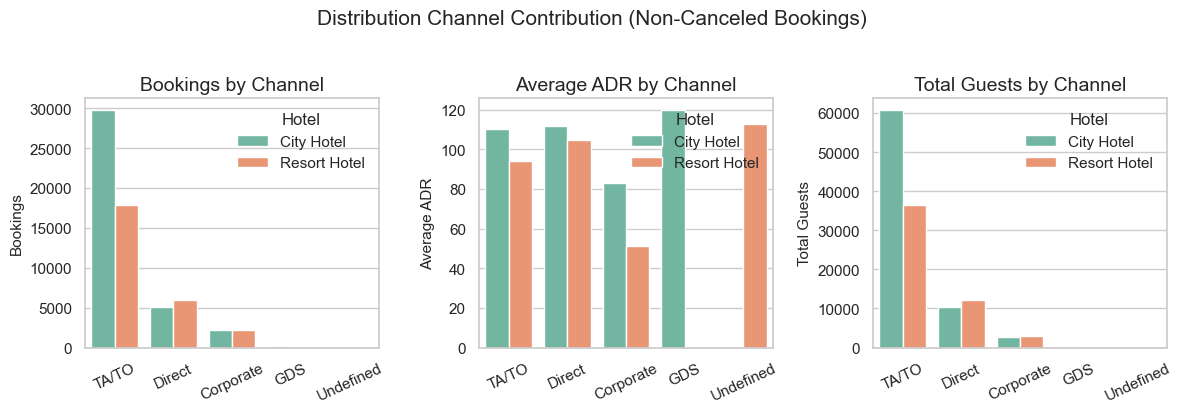

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sns.barplot(
    data=channel_contribution,
    x="distribution_channel",
    y="bookings",
    hue="hotel",
    order=channel_order,
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Bookings by Channel")
axes[0].set_xlabel("")
axes[0].set_ylabel("Bookings")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(title="Hotel", frameon=False)

sns.barplot(
    data = channel_contribution,
    x = "distribution_channel",
    y = 
)

sns.barplot(
    data=channel_contribution,
    x="distribution_channel",
    y="avg_adr",
    hue="hotel",
    order=channel_order,
    palette="Set2",
    ax=axes[1]
)
axes[2].set_title("Average ADR by Channel")
axes[2].set_xlabel("")
axes[2].set_ylabel("Average ADR")
axes[2].tick_params(axis="x", rotation=25)
axes[2].legend(title="Hotel", frameon=False)

sns.barplot(
    data=channel_contribution,
    x="distribution_channel",
    y="total_guests",
    hue="hotel",
    order=channel_order,
    palette="Set2",
    ax=axes[2]
)
axes[3].set_title("Total Guests by Channel")
axes[3].set_xlabel("")
axes[3].set_ylabel("Total Guests")
axes[3].tick_params(axis="x", rotation=25)
axes[3].legend(title="Hotel", frameon=False)

fig.suptitle("Distribution Channel Contribution (Non-Canceled Bookings)", y=1.03, fontsize=15)
plt.tight_layout()
plt.show()


从分销渠道来看，

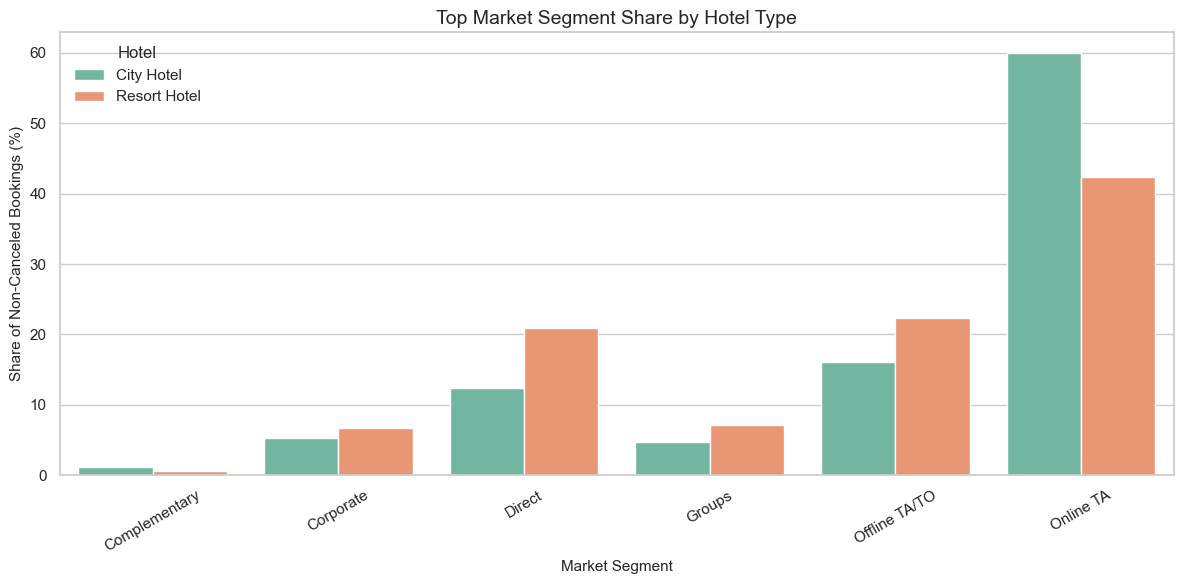

In [23]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=market_segment_share[market_segment_share["market_segment"].isin(top_market_segments)],
    x="market_segment",
    y="share_pct",
    hue="hotel",
    palette="Set2"
)
plt.title("Top Market Segment Share by Hotel Type")
plt.xlabel("Market Segment")
plt.ylabel("Share of Non-Canceled Bookings (%)")
plt.xticks(rotation=30)
plt.legend(title="Hotel", frameon=False)
plt.tight_layout()
plt.show()


### EDA 1.6 Operational Volume

This block looks at monthly guest volume and guest mix to identify the busiest periods and the composition of demand.


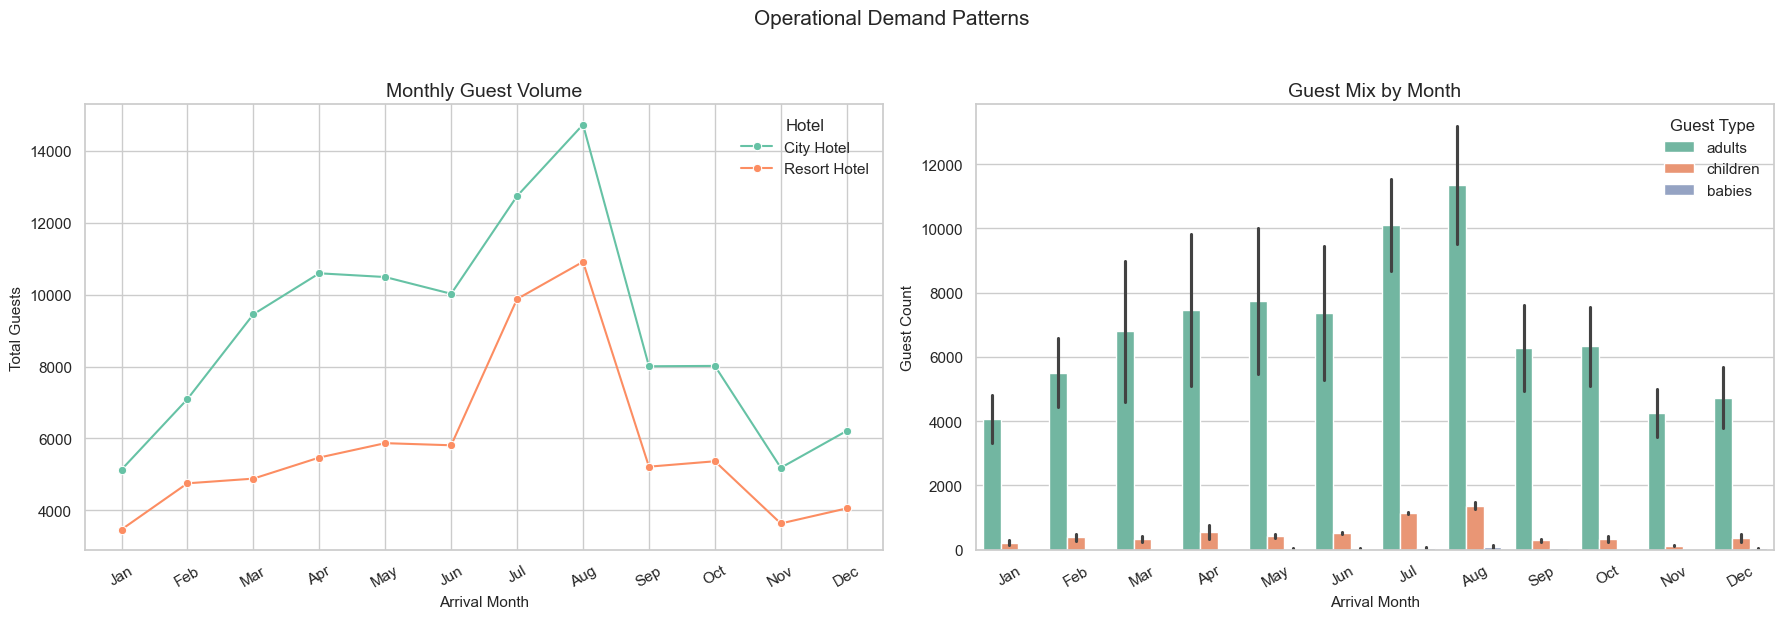

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(
    data=monthly_guest_volume,
    x="arrival_month_short",
    y="total_guests",
    hue="hotel",
    marker="o",
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Monthly Guest Volume")
axes[0].set_xlabel("Arrival Month")
axes[0].set_ylabel("Total Guests")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Hotel", frameon=False)

sns.barplot(
    data=monthly_guest_mix,
    x="arrival_month_short",
    y="guest_count",
    hue="guest_type",
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("Guest Mix by Month")
axes[1].set_xlabel("Arrival Month")
axes[1].set_ylabel("Guest Count")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Guest Type", frameon=False)

fig.suptitle("Operational Demand Patterns", y=1.03, fontsize=15)
plt.tight_layout()
plt.show()


### Initial Booking Pattern Insights

- Are City Hotel and Resort Hotel showing different booking lead time patterns?
- Are bookings concentrated in a small number of origin countries?
- Do room type and hotel category show clearly different ADR structures?
- Are there visible seasonal changes in ADR and guest volume?
- Which channels and segments contribute most to stable booking volume?


In [25]:
cancellation_rate = df_clean["is_canceled"].mean()
print(f"Overall cancellation rate: {cancellation_rate:.2%}")

hotel_cancel = (
    df_clean.groupby("hotel")["is_canceled"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "cancel_rate", "count": "bookings"})
    .sort_values("cancel_rate", ascending=False)
)

customer_type_cancel = (
    df_clean.groupby(["customer_type", "hotel"])["is_canceled"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "cancel_rate", "count": "bookings"})
)

country_order = df_clean["country"].value_counts().head(8).index.tolist()
country_cancel = (
    df_clean[df_clean["country"].isin(country_order)]
    .groupby(["country", "hotel"])["is_canceled"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "cancel_rate", "count": "bookings"})
)

family_cancel = (
    df_clean.groupby(["is_family", "hotel"])["is_canceled"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "cancel_rate", "count": "bookings"})
)
family_cancel["is_family_label"] = family_cancel["is_family"].map({0: "Non-family", 1: "Family"})

lead_time_band_order = ["0-7", "8-30", "31-90", "91-180", "181+"]
df_clean["lead_time_band"] = pd.cut(
    df_clean["lead_time"],
    bins=[-1, 7, 30, 90, 180, np.inf],
    labels=lead_time_band_order
)
lead_time_cancel = (
    df_clean.groupby(["lead_time_band", "hotel"], observed=False)["is_canceled"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "cancel_rate", "count": "bookings"})
)

booking_behavior_channel = (
    df_clean.groupby(["distribution_channel", "hotel"])["is_canceled"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "cancel_rate", "count": "bookings"})
)

deposit_cancel = (
    df_clean.groupby(["deposit_type", "hotel"])["is_canceled"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "cancel_rate", "count": "bookings"})
)

segment_order = df_clean["market_segment"].value_counts().head(6).index.tolist()
market_segment_cancel = (
    df_clean[df_clean["market_segment"].isin(segment_order)]
    .groupby(["market_segment", "hotel"])["is_canceled"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "cancel_rate", "count": "bookings"})
)

distribution_channel_order = df_clean["distribution_channel"].value_counts().index.tolist()
distribution_channel_cancel = (
    df_clean.groupby(["distribution_channel", "hotel"])["is_canceled"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "cancel_rate", "count": "bookings"})
)

top_agent_ids = (
    df_clean["agent"].dropna().astype(str).value_counts().head(8).index.tolist()
)
agent_cancel = (
    df_clean[df_clean["agent"].astype(str).isin(top_agent_ids)]
    .groupby(["agent", "hotel"])["is_canceled"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "cancel_rate", "count": "bookings"})
)

hotel_cancel


Overall cancellation rate: 27.52%


,cancel_rate,bookings
hotel,,
City Hotel,0.300991,53274
Resort Hotel,0.234840,33955


## EDA 2. Customer Analysis

This block explores whether guest profile differences are associated with different cancellation patterns across hotel types.


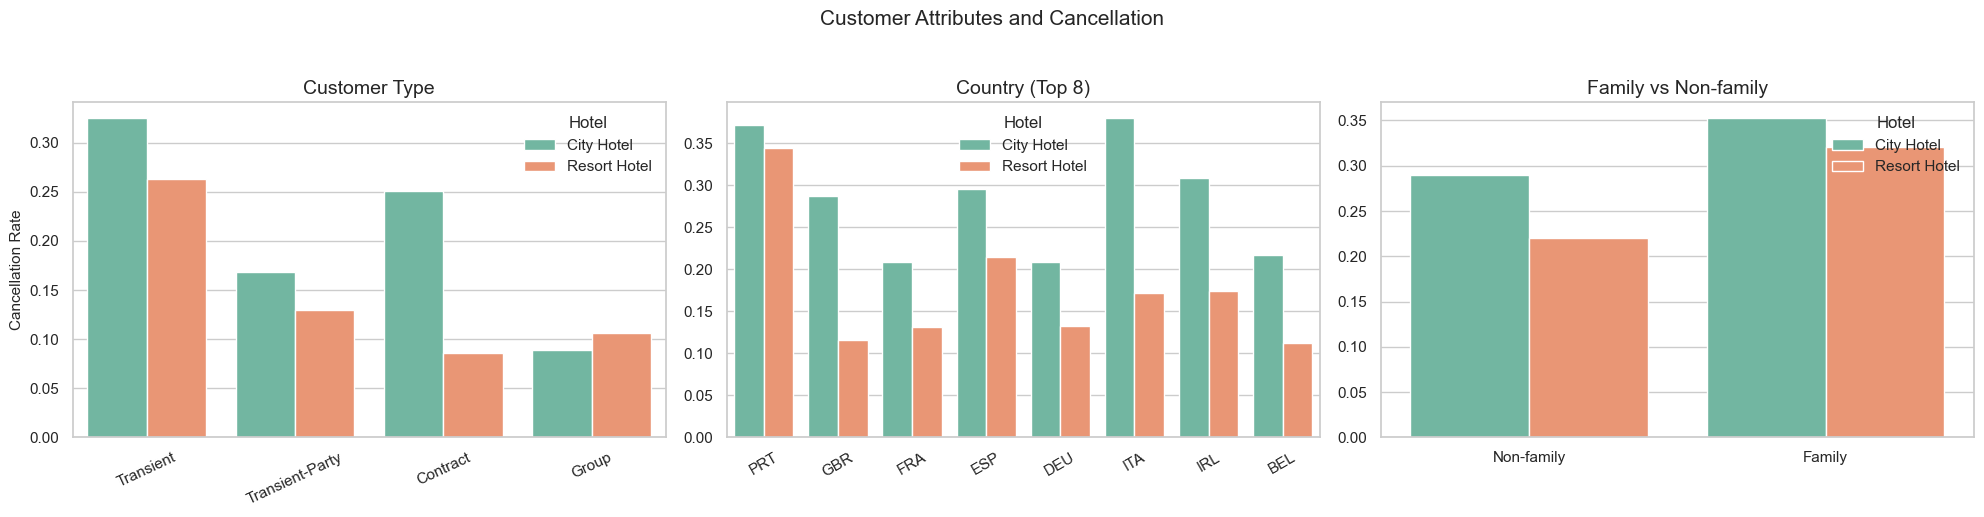

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.barplot(
    data=customer_type_cancel,
    x="customer_type",
    y="cancel_rate",
    hue="hotel",
    order=customer_type_cancel.groupby("customer_type")["bookings"].sum().sort_values(ascending=False).index,
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Customer Type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Cancellation Rate")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(title="Hotel", frameon=False)

sns.barplot(
    data=country_cancel,
    x="country",
    y="cancel_rate",
    hue="hotel",
    order=country_order,
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("Country (Top 8)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Hotel", frameon=False)

sns.barplot(
    data=family_cancel,
    x="is_family_label",
    y="cancel_rate",
    hue="hotel",
    palette="Set2",
    ax=axes[2]
)
axes[2].set_title("Family vs Non-family")
axes[2].set_xlabel("")
axes[2].set_ylabel("")
axes[2].legend(title="Hotel", frameon=False)

fig.suptitle("Customer Attributes and Cancellation", y=1.03, fontsize=15)
plt.tight_layout()
plt.show()


In [27]:
display(customer_type_cancel.sort_values(["customer_type", "hotel"]).reset_index(drop=True))
display(country_cancel.sort_values(["country", "hotel"]).reset_index(drop=True))
display(family_cancel[["is_family_label", "hotel", "cancel_rate", "bookings"]].sort_values(["is_family_label", "hotel"]).reset_index(drop=True))


,customer_type,hotel,cancel_rate,bookings
0,Contract,City Hotel,0.250852,1467
1,Contract,Resort Hotel,0.086331,1668
2,Group,City Hotel,0.089219,269
3,Group,Resort Hotel,0.106618,272
4,Transient,City Hotel,0.324873,44522
5,Transient,Resort Hotel,0.263241,27340
6,Transient-Party,City Hotel,0.168044,7016
7,Transient-Party,Resort Hotel,0.129198,4675


,country,hotel,cancel_rate,bookings
0,BEL,City Hotel,0.217160,1690
1,BEL,Resort Hotel,0.112532,391
2,DEU,City Hotel,0.208511,4465
3,DEU,Resort Hotel,0.132609,920
4,ESP,City Hotel,0.296002,3777
5,ESP,Resort Hotel,0.214595,3467
6,FRA,City Hotel,0.208812,7399
7,FRA,Resort Hotel,0.131320,1424
8,GBR,City Hotel,0.287168,4520
9,GBR,Resort Hotel,0.116212,5903


,is_family_label,hotel,cancel_rate,bookings
0,Family,City Hotel,0.352428,9287
1,Family,Resort Hotel,0.320316,4814
2,Non-family,City Hotel,0.290131,43987
3,Non-family,Resort Hotel,0.220720,29141


### Initial Customer Analysis Insights

- Which customer types are most cancellation-prone in City Hotel versus Resort Hotel?
- Do certain origin countries show consistently higher cancellation risk?
- Does family travel appear more or less stable than non-family travel?


## EDA 3. Booking Behavior

This block explores booking behavior before arrival. These variables are often operationally useful because they can inform cancellation policies and forecasting logic.


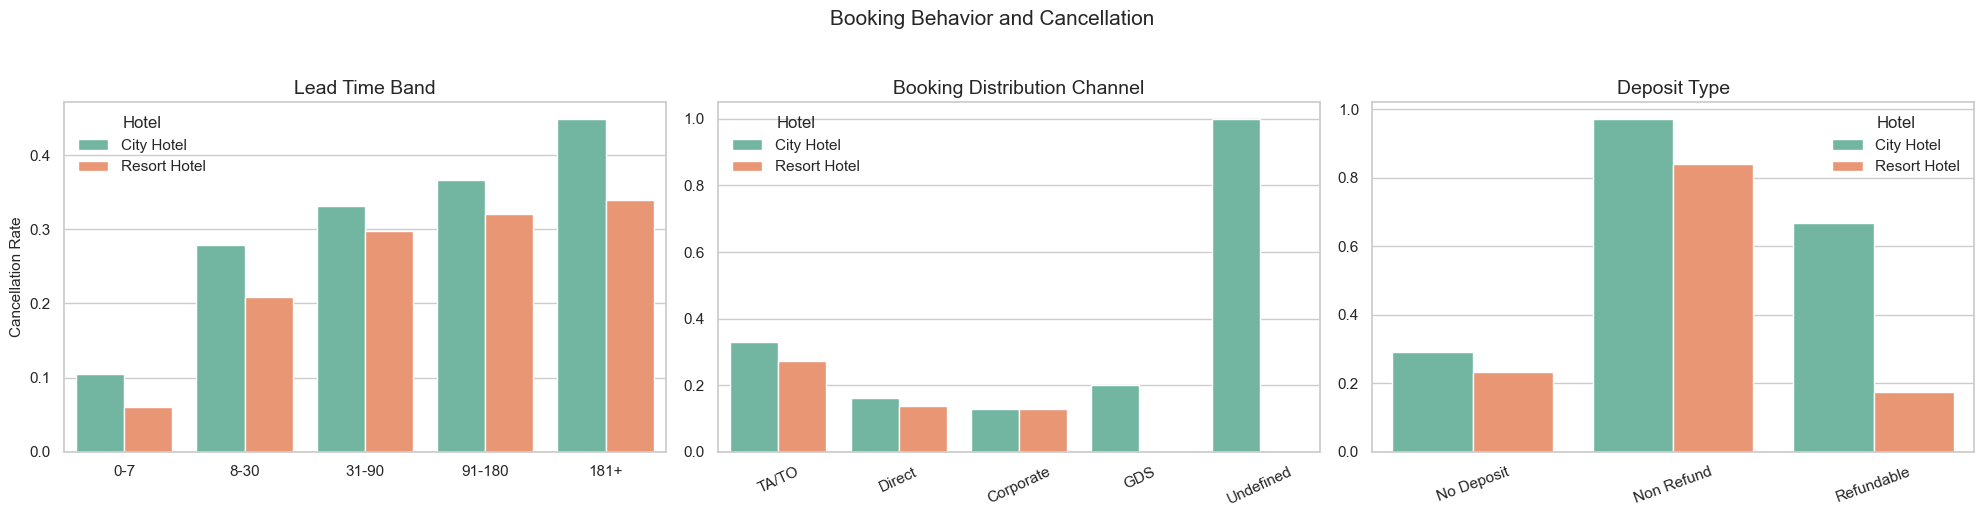

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.barplot(
    data=lead_time_cancel,
    x="lead_time_band",
    y="cancel_rate",
    hue="hotel",
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Lead Time Band")
axes[0].set_xlabel("")
axes[0].set_ylabel("Cancellation Rate")
axes[0].legend(title="Hotel", frameon=False)

sns.barplot(
    data=booking_behavior_channel,
    x="distribution_channel",
    y="cancel_rate",
    hue="hotel",
    order=distribution_channel_order,
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("Booking Distribution Channel")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(title="Hotel", frameon=False)

sns.barplot(
    data=deposit_cancel,
    x="deposit_type",
    y="cancel_rate",
    hue="hotel",
    palette="Set2",
    ax=axes[2]
)
axes[2].set_title("Deposit Type")
axes[2].set_xlabel("")
axes[2].set_ylabel("")
axes[2].tick_params(axis="x", rotation=20)
axes[2].legend(title="Hotel", frameon=False)

fig.suptitle("Booking Behavior and Cancellation", y=1.03, fontsize=15)
plt.tight_layout()
plt.show()


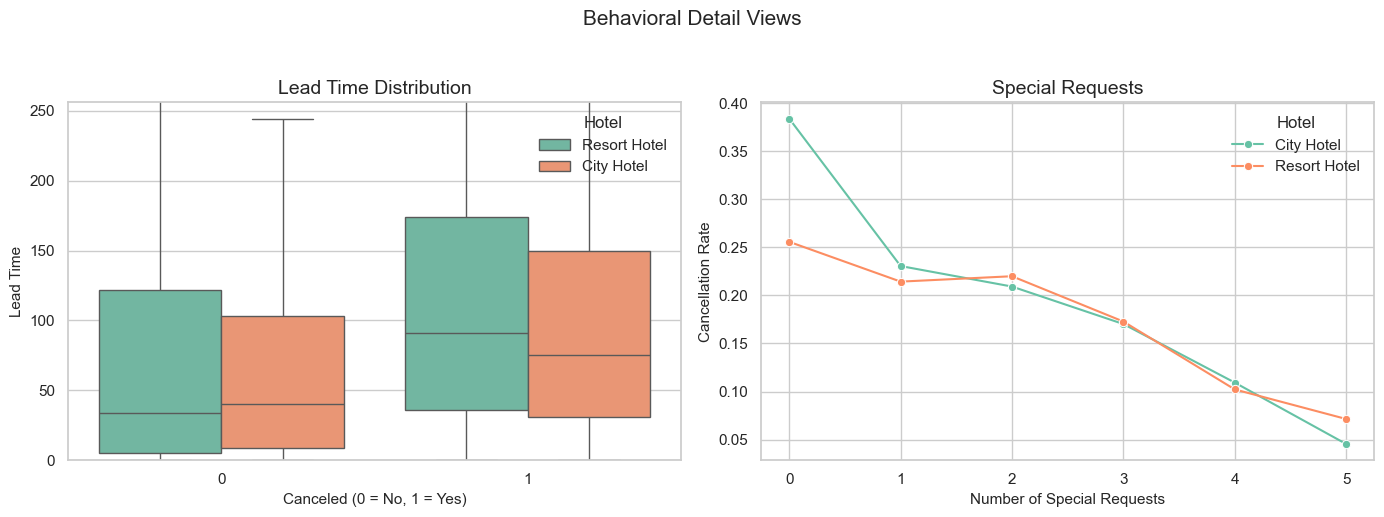

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df_clean,
    x="is_canceled",
    y="lead_time",
    hue="hotel",
    showfliers=False,
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Lead Time Distribution")
axes[0].set_xlabel("Canceled (0 = No, 1 = Yes)")
axes[0].set_ylabel("Lead Time")
axes[0].set_ylim(0, df_clean["lead_time"].quantile(0.95))
axes[0].legend(title="Hotel", frameon=False)

request_plot = (
    df_clean.groupby(["total_of_special_requests", "hotel"])["is_canceled"]
    .mean()
    .reset_index(name="cancel_rate")
)
sns.lineplot(
    data=request_plot,
    x="total_of_special_requests",
    y="cancel_rate",
    hue="hotel",
    marker="o",
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("Special Requests")
axes[1].set_xlabel("Number of Special Requests")
axes[1].set_ylabel("Cancellation Rate")
axes[1].legend(title="Hotel", frameon=False)

fig.suptitle("Behavioral Detail Views", y=1.03, fontsize=15)
plt.tight_layout()
plt.show()


In [30]:
display(lead_time_cancel.sort_values(["lead_time_band", "hotel"]).reset_index(drop=True))
display(booking_behavior_channel.sort_values(["distribution_channel", "hotel"]).reset_index(drop=True))
display(deposit_cancel.sort_values(["deposit_type", "hotel"]).reset_index(drop=True))


,lead_time_band,hotel,cancel_rate,bookings
0,0-7,City Hotel,0.105102,9800
1,0-7,Resort Hotel,0.059741,8403
2,8-30,City Hotel,0.278882,10517
3,8-30,Resort Hotel,0.208642,5809
4,31-90,City Hotel,0.331552,15156
5,31-90,Resort Hotel,0.298123,7564
6,91-180,City Hotel,0.367169,11556
7,91-180,Resort Hotel,0.320486,6668
8,181+,City Hotel,0.448999,6245
9,181+,Resort Hotel,0.338958,5511


,distribution_channel,hotel,cancel_rate,bookings
0,Corporate,City Hotel,0.127364,2591
1,Corporate,Resort Hotel,0.127883,2471
2,Direct,City Hotel,0.160337,6056
3,Direct,Resort Hotel,0.138031,6897
4,GDS,City Hotel,0.198895,181
5,TA/TO,City Hotel,0.330633,44442
6,TA/TO,Resort Hotel,0.272757,24586
7,Undefined,City Hotel,1.000000,4
8,Undefined,Resort Hotel,0.000000,1


,deposit_type,hotel,cancel_rate,bookings
0,No Deposit,City Hotel,0.290075,52414
1,No Deposit,Resort Hotel,0.231541,33670
2,Non Refund,City Hotel,0.971598,845
3,Non Refund,Resort Hotel,0.839378,193
4,Refundable,City Hotel,0.666667,15
5,Refundable,Resort Hotel,0.173913,92


### Initial Booking Behavior Insights

- Does longer lead time consistently correspond to higher cancellation risk?
- Are some distribution channels materially more unstable than others?
- Does deposit policy appear to reduce cancellation risk differently across hotel types?


## EDA 4. Cancellation Analysis

This block focuses on cancellation differences across channel and policy dimensions. These views are useful for partner management, channel quality evaluation, and cancellation policy decisions.


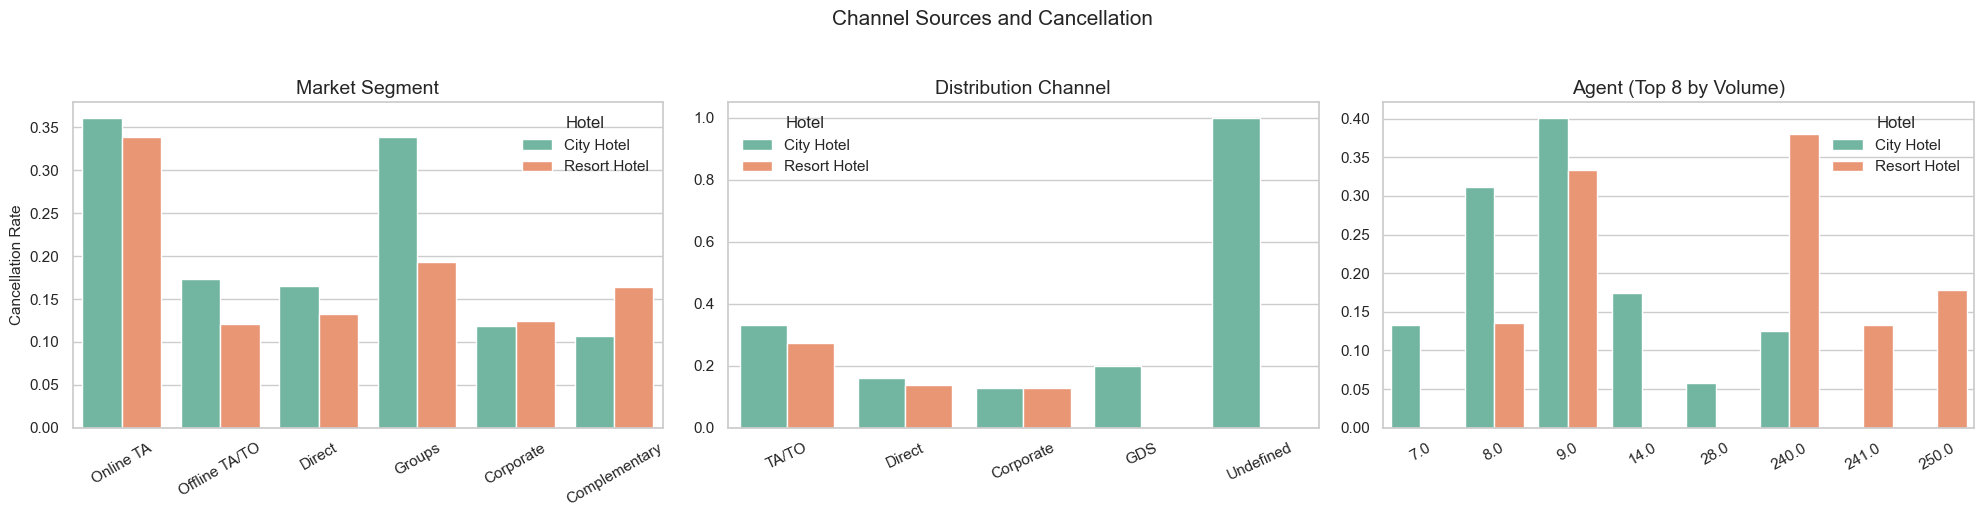

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.barplot(
    data=market_segment_cancel,
    x="market_segment",
    y="cancel_rate",
    hue="hotel",
    order=segment_order,
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Market Segment")
axes[0].set_xlabel("")
axes[0].set_ylabel("Cancellation Rate")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Hotel", frameon=False)

sns.barplot(
    data=distribution_channel_cancel,
    x="distribution_channel",
    y="cancel_rate",
    hue="hotel",
    order=distribution_channel_order,
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("Distribution Channel")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(title="Hotel", frameon=False)

sns.barplot(
    data=agent_cancel,
    x="agent",
    y="cancel_rate",
    hue="hotel",
    palette="Set2",
    ax=axes[2]
)
axes[2].set_title("Agent (Top 8 by Volume)")
axes[2].set_xlabel("")
axes[2].set_ylabel("")
axes[2].tick_params(axis="x", rotation=30)
axes[2].legend(title="Hotel", frameon=False)

fig.suptitle("Channel Sources and Cancellation", y=1.03, fontsize=15)
plt.tight_layout()
plt.show()


In [32]:
display(market_segment_cancel.sort_values(["market_segment", "hotel"]).reset_index(drop=True))
display(distribution_channel_cancel.sort_values(["distribution_channel", "hotel"]).reset_index(drop=True))
display(agent_cancel.sort_values(["agent", "hotel"]).reset_index(drop=True))


,market_segment,hotel,cancel_rate,bookings
0,Complementary,City Hotel,0.107356,503
1,Complementary,Resort Hotel,0.164021,189
2,Corporate,City Hotel,0.118575,2218
3,Corporate,Resort Hotel,0.124117,1982
4,Direct,City Hotel,0.164680,5538
5,Direct,Resort Hotel,0.132169,6242
6,Groups,City Hotel,0.338679,2619
7,Groups,Resort Hotel,0.193310,2302
8,Offline TA/TO,City Hotel,0.173643,7239
9,Offline TA/TO,Resort Hotel,0.120919,6616


,distribution_channel,hotel,cancel_rate,bookings
0,Corporate,City Hotel,0.127364,2591
1,Corporate,Resort Hotel,0.127883,2471
2,Direct,City Hotel,0.160337,6056
3,Direct,Resort Hotel,0.138031,6897
4,GDS,City Hotel,0.198895,181
5,TA/TO,City Hotel,0.330633,44442
6,TA/TO,Resort Hotel,0.272757,24586
7,Undefined,City Hotel,1.000000,4
8,Undefined,Resort Hotel,0.000000,1


,agent,hotel,cancel_rate,bookings
0,7.0,City Hotel,0.132362,3294
1,8.0,City Hotel,0.312165,1118
2,8.0,Resort Hotel,0.135849,265
3,9.0,City Hotel,0.401184,28715
4,9.0,Resort Hotel,0.333333,6
5,14.0,City Hotel,0.174446,3342
6,28.0,City Hotel,0.058272,1493
7,240.0,City Hotel,0.125000,8
8,240.0,Resort Hotel,0.379647,13020
9,241.0,Resort Hotel,0.132603,1644


### Initial Cancellation Analysis Insights

- Which segments bring high volume but weak booking stability?
- Are there channel differences that vary sharply between City Hotel and Resort Hotel?
- Do some agents appear associated with much higher cancellation rates than others?

## Next Steps

- Expand Booking Patterns to cover monthly price patterns, channel contribution, and operational volume views
- Turn the strongest EDA findings into concise written insights
- Add a dedicated Key Insights section after the main EDA blocks
- Connect the strongest findings to later ML verification
